# 🎵 Prueba del Modelo de Clasificación de Audio

Este notebook carga el modelo entrenado y hace predicciones en audios de una carpeta.

In [21]:
# 📦 Importaciones
import os
import sys
import glob
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import librosa
import librosa.display
from IPython.display import Audio, display
from src.utils.config import *
print("✅ Importaciones completadas")

✅ Importaciones completadas


## 1️⃣ Cargar el modelo entrenado

In [22]:
# 🔧 CONFIGURACIÓN

# Ruta del modelo entrenado
MODEL_PATH = CHECKPOINT_DIR / "checkpoint_epoch_12.pt"

# Ruta del label mapping
LABEL_MAPPING_PATH = LABEL_MAPPING["human_label"]

# Carpeta con audios para probar
AUDIO_FOLDER = TEST_AUDIO_FOLDER

# Configuración de audio
SAMPLE_RATE = 22050
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Device: {DEVICE}")
print(f"📂 Carpeta de audios: {AUDIO_FOLDER}")
print(f"💾 Modelo: {MODEL_PATH}")
print(f"🏷️ Label mapping: {LABEL_MAPPING_PATH}")

🚀 Device: cuda
📂 Carpeta de audios: /home/andres/Documentos/proyecto4geeks/tests/audios
💾 Modelo: /home/andres/Documentos/proyecto4geeks/models/checkpoints/checkpoint_epoch_12.pt
🏷️ Label mapping: /home/andres/Documentos/proyecto4geeks/data/interim/processed_dataset/label_mapping_human_label.pkl


In [23]:
# 📥 Cargar label mapping
with open(LABEL_MAPPING_PATH, 'rb') as f:
    label_mapping = pickle.load(f)

# Extraer label2idx e idx2label
if isinstance(label_mapping, dict) and 'label2idx' in label_mapping:
    label2idx = label_mapping['label2idx']
    idx2label = label_mapping.get('idx2label', {int(v): k for k, v in label2idx.items()})
else:
    label2idx = label_mapping
    idx2label = {int(v): k for k, v in label2idx.items()}

num_classes = len(label2idx)

print(f"✅ Label mapping cargado: {num_classes} clases")
print(f"\n📋 Primeras 10 clases:")
for i, (label, idx) in enumerate(list(label2idx.items())[:10]):
    print(f"   {idx}: {label}")

✅ Label mapping cargado: 23 clases

📋 Primeras 10 clases:
   0: alert_sirem
   1: ambient_noise
   2: another_animal
   3: breathing
   4: car_crash
   5: construction_noise
   6: crime
   7: crying
   8: dog
   9: domestic_activity


In [24]:
# 🧠 Cargar el modelo
from src.models.hybrid_cnn import ImprovedMFCCCNN

model = ImprovedMFCCCNN(num_classes=num_classes, dropout=0.25).to(DEVICE)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

model.load_state_dict(checkpoint["model_state"])
model.eval()
# model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
# model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modelo cargado")
print(f"   - Parámetros: {total_params:,}")
print(f"   - Clases: {num_classes}")

✅ Modelo cargado
   - Parámetros: 1,180,375
   - Clases: 23


## 2️⃣ Procesar y predecir audios

In [25]:
def cargar_audio(audio_path, sr=SAMPLE_RATE, duration=None):
    """Carga un audio y devuelve la onda."""
    try:
        y, sr_loaded = librosa.load(audio_path, sr=sr, duration=duration)
        return y, sr_loaded
    except Exception as e:
        print(f"❌ Error cargando {audio_path}: {e}")
        return None, None

def audio_a_mel(y, sr=SAMPLE_RATE, n_mels=N_MELS, hop_length=HOP_LENGTH, n_fft=N_FFT):
    """Convierte audio a mel-spectrogram."""
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db

def normalizar_mel(mel_spec, target_frames=360):
    """Normaliza el mel-spectrogram al tamaño esperado."""
    frames = mel_spec.shape[-1]
    
    if frames > target_frames:
        mel_spec = mel_spec[:, :target_frames]
    elif frames < target_frames:
        pad = target_frames - frames
        mel_spec = np.pad(mel_spec, ((0, 0), (0, pad)), mode='constant')
    
    return mel_spec.astype(np.float32)

print("✅ Funciones de procesamiento de audio definidas")

✅ Funciones de procesamiento de audio definidas


In [26]:
def predecir_audio(model, audio_path, device=DEVICE):
    """Hace predicción en un audio."""
    
    # Cargar audio
    y, sr = cargar_audio(audio_path)
    if y is None:
        return None
    
    # Convertir a mel-spectrogram
    mel_spec = audio_a_mel(y, sr=sr)
    mel_spec = normalizar_mel(mel_spec, target_frames=360)
    
    # Preparar para el modelo
    mel_tensor = torch.from_numpy(mel_spec).unsqueeze(0).unsqueeze(0).to(device)  # [1, 1, 128, 360]
    
    # Predicción
    with torch.no_grad():
        logits = model(mel_tensor)
        probs = torch.softmax(logits, dim=1)
        confidence, predicted_idx = torch.max(probs, 1)
    
    predicted_idx = predicted_idx.item()
    confidence = confidence.item()
    predicted_label = idx2label.get(predicted_idx, "DESCONOCIDO")
    
    # Top 5 predicciones
    top5_probs, top5_indices = torch.topk(probs[0], k=min(5, len(probs[0])))
    top5 = [(idx2label.get(idx.item(), "DESCONOCIDO"), prob.item()) 
            for idx, prob in zip(top5_indices, top5_probs)]
    
    return {
        'predicted_label': predicted_label,
        'predicted_idx': predicted_idx,
        'confidence': confidence,
        'top5': top5,
        'mel_spec': mel_spec,
        'audio_path': audio_path
    }

print("✅ Función de predicción definida")

✅ Función de predicción definida


In [27]:
# 🔍 Buscar audios en la carpeta
audio_extensions = ['*.mp3', '*.wav', '*.flac', '*.ogg', '*.m4a']
audio_files = []

for ext in audio_extensions:
    audio_files.extend(glob.glob(str(AUDIO_FOLDER / ext)))
    audio_files.extend(glob.glob(str(AUDIO_FOLDER / ext.upper())))

audio_files = list(set(audio_files))  # Eliminar duplicados

print(f"📂 Encontrados {len(audio_files)} audios en {AUDIO_FOLDER}")

if len(audio_files) == 0:
    print(f"\n⚠️ No se encontraron audios. Crea la carpeta y añade archivos:")
    print(f"   mkdir -p {AUDIO_FOLDER}")
    print(f"   cp /ruta/a/tus/audios/* {AUDIO_FOLDER}/")
else:
    print(f"\n📋 Primeros 5 audios:")
    for i, audio_file in enumerate(audio_files[:5]):
        print(f"   {i+1}. {Path(audio_file).name}")

📂 Encontrados 2 audios en /home/andres/Documentos/proyecto4geeks/tests/audios

📋 Primeros 5 audios:
   1. m4a1_unsil-1_d6515.mp3
   2. audio_607a0.mp3


In [28]:
# 🎯 Hacer predicciones en todos los audios
results = []

print(f"\n🔮 Haciendo predicciones...\n")

for i, audio_file in enumerate(audio_files):
    print(f"[{i+1}/{len(audio_files)}] {Path(audio_file).name}...", end=" ", flush=True)
    
    result = predecir_audio(model, audio_file)
    
    if result:
        results.append(result)
        confidence_pct = result['confidence'] * 100
        print(f"✅ {result['predicted_label']} ({confidence_pct:.1f}%)")
    else:
        print(f"❌ Error")

print(f"\n✅ Predicciones completadas: {len(results)}/{len(audio_files)}")


🔮 Haciendo predicciones...

[1/2] m4a1_unsil-1_d6515.mp3... ✅ fire (27.7%)
[2/2] audio_607a0.mp3... ✅ instrument (27.2%)

✅ Predicciones completadas: 2/2


## 3️⃣ Mostrar resultados

In [29]:
# 📊 Tabla de resultados
df_results = pd.DataFrame([
    {
        'Archivo': Path(r['audio_path']).name,
        'Predicción': r['predicted_label'],
        'Confianza': f"{r['confidence']*100:.2f}%",
        'Confianza (valor)': r['confidence']
    }
    for r in results
])

# Ordenar por confianza descendente
df_results = df_results.sort_values('Confianza (valor)', ascending=False)

print("\n" + "="*80)
print("📊 RESULTADOS DE PREDICCIONES")
print("="*80)
print(df_results[['Archivo', 'Predicción', 'Confianza']].to_string(index=False))
print("="*80)


📊 RESULTADOS DE PREDICCIONES
               Archivo Predicción Confianza
m4a1_unsil-1_d6515.mp3       fire    27.73%
       audio_607a0.mp3 instrument    27.16%


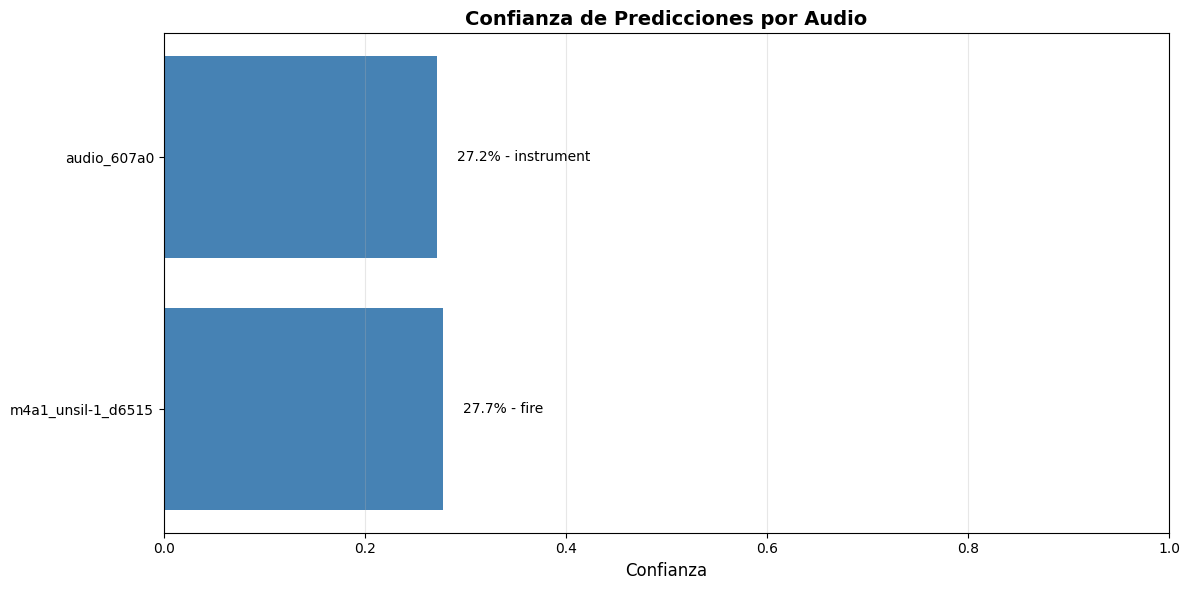

In [30]:
# 📈 Gráfico de confianzas
plt.figure(figsize=(12, 6))
plt.barh(range(len(df_results)), df_results['Confianza (valor)'].values, color='steelblue')
plt.yticks(range(len(df_results)), [Path(p).stem for p in df_results['Archivo'].values])
plt.xlabel('Confianza', fontsize=12)
plt.title('Confianza de Predicciones por Audio', fontsize=14, fontweight='bold')
plt.xlim([0, 1])
plt.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, (conf, audio) in enumerate(zip(df_results['Confianza (valor)'].values, 
                                        df_results['Predicción'].values)):
    plt.text(conf + 0.02, i, f"{conf*100:.1f}% - {audio}", 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 4️⃣ Detalles por audio


📁 Audio 1: m4a1_unsil-1_d6515.mp3

🎯 PREDICCIÓN PRINCIPAL:
   Clase: fire
   Confianza: 27.73%

🏆 TOP 5 PREDICCIONES:
   1. fire                           - 27.73%
   2. weather                        - 15.53%
   3. traffic                        - 10.55%
   4. glass_metal                    -  8.95%
   5. domestic_activity              -  8.80%


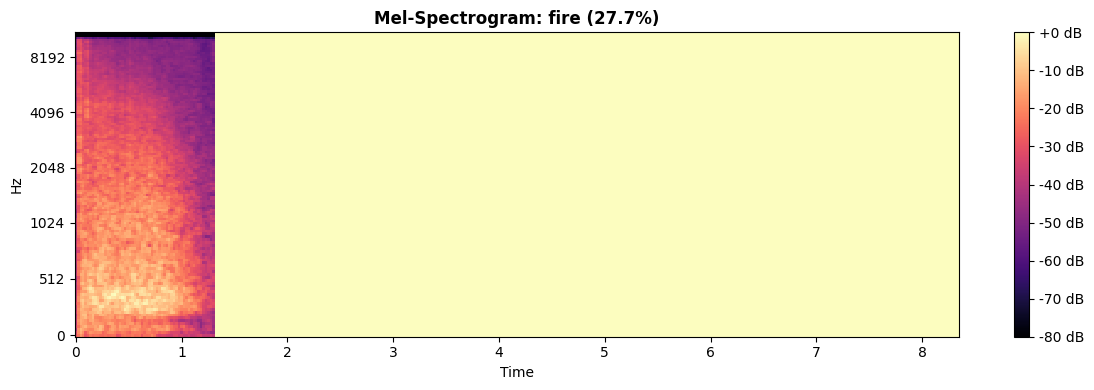


🔊 Audio:



📁 Audio 2: audio_607a0.mp3

🎯 PREDICCIÓN PRINCIPAL:
   Clase: instrument
   Confianza: 27.16%

🏆 TOP 5 PREDICCIONES:
   1. instrument                     - 27.16%
   2. traffic                        - 16.89%
   3. water                          - 12.16%
   4. weather                        - 10.25%
   5. doors                          -  6.49%


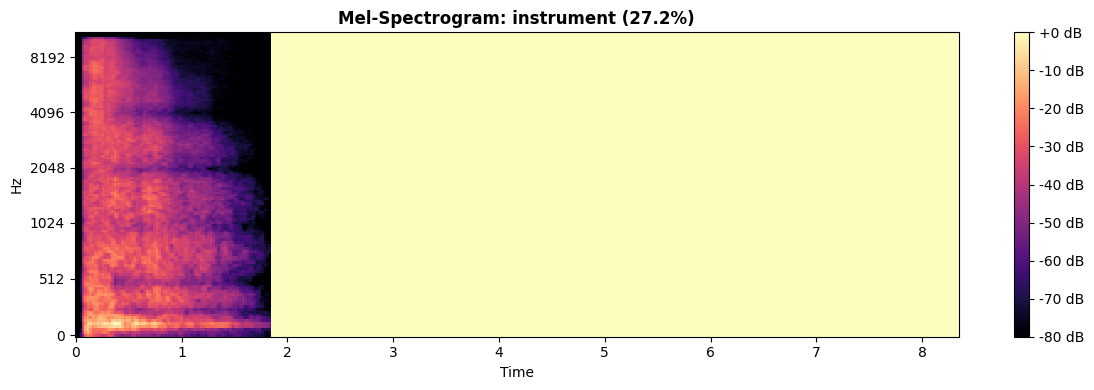


🔊 Audio:


In [31]:
# 🔍 Mostrar detalles de cada audio con el mel-spectrogram
for idx, result in enumerate(results):
    print(f"\n{'='*80}")
    print(f"📁 Audio {idx+1}: {Path(result['audio_path']).name}")
    print(f"{'='*80}")
    
    # Información principal
    print(f"\n🎯 PREDICCIÓN PRINCIPAL:")
    print(f"   Clase: {result['predicted_label']}")
    print(f"   Confianza: {result['confidence']*100:.2f}%")
    
    # Top 5
    print(f"\n🏆 TOP 5 PREDICCIONES:")
    for rank, (label, prob) in enumerate(result['top5'], 1):
        print(f"   {rank}. {label:30s} - {prob*100:5.2f}%")
    
    # Visualizar mel-spectrogram
    fig, ax = plt.subplots(figsize=(12, 4))
    mel_spec = result['mel_spec']
    img = librosa.display.specshow(mel_spec, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, 
                                    x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    ax.set_title(f"Mel-Spectrogram: {result['predicted_label']} ({result['confidence']*100:.1f}%)", 
                fontsize=12, fontweight='bold')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()
    
    # Reproducir audio
    print(f"\n🔊 Audio:")
    display(Audio(result['audio_path']))

## 5️⃣ Estadísticas generales

In [32]:
# 📊 Estadísticas
confidences = df_results['Confianza (valor)'].values

print(f"\n{'='*80}")
print("📊 ESTADÍSTICAS GENERALES")
print(f"{'='*80}")
print(f"Total de audios: {len(results)}")
print(f"Confianza promedio: {np.mean(confidences)*100:.2f}%")
print(f"Confianza máxima: {np.max(confidences)*100:.2f}%")
print(f"Confianza mínima: {np.min(confidences)*100:.2f}%")
print(f"Desviación estándar: {np.std(confidences)*100:.2f}%")

# Clases predichas
print(f"\n🏷️ CLASES PREDICHAS:")
class_counts = df_results['Predicción'].value_counts()
for label, count in class_counts.items():
    percentage = (count / len(results)) * 100
    print(f"   {label:30s} - {count} ({percentage:.1f}%)")

print(f"{'='*80}")


📊 ESTADÍSTICAS GENERALES
Total de audios: 2
Confianza promedio: 27.45%
Confianza máxima: 27.73%
Confianza mínima: 27.16%
Desviación estándar: 0.28%

🏷️ CLASES PREDICHAS:
   fire                           - 1 (50.0%)
   instrument                     - 1 (50.0%)


In [33]:
# 📥 Exportar resultados a CSV (opcional)
csv_path = AUDIO_FOLDER / "predicciones.csv"
df_results[['Archivo', 'Predicción', 'Confianza']].to_csv(csv_path, index=False)
print(f"\n✅ Resultados exportados a: {csv_path}")


✅ Resultados exportados a: /home/andres/Documentos/proyecto4geeks/tests/audios/predicciones.csv
